# Detección y Análisis de Reseñas Duplicadas (20 vs 150 Palabras y Sentimiento)

**Objetivo del notebook:**
1. Analizar e identificar reseñas duplicadas en el dataset de IMDB considerando las **primeras 20 palabras** y las **primeras 150 palabras**, condicionadas a que compartan el mismo **sentimiento** (`sentiment`).
2. Evaluar el impacto probabilístico y de filtrado al aumentar el umbral de prefijo ($k=20 \to k=150$).
3. Presentar una **celda concisa de inspección textual** para comparar directamente reseñas duplicadas representativas de distintas categorías (idénticas al 100%, variaciones con anexos finales y divergencias de desarrollo).


## 1. Fundamentos Matemáticos: Efecto del Umbral de Prefijo ($k=20$ vs $k=150$)

### 1.1 Formulación Probabilística de Colisiones
Definimos el operador de prefijo $f_k: \mathcal{V}^* \to \mathcal{V}^{\le k}$ sobre una secuencia de palabras $x_i$:
$$f_k(x_i) = (w_1^{(i)}, w_2^{(i)}, \dots, w_{\min(|x_i|, k)}^{(i)})$$

La relación de equivalencia condicionada por sentimiento es:
$$i \sim_k j \iff f_k(x_i) = f_k(x_j) \;\land\; y_i = y_j$$

### 1.2 Análisis de Compensación (Trade-off) Sesgo-Varianza en la Detección:
- **Con $k=20$ palabras:**
  - *Ventaja:* Mayor sensibilidad para capturar plagios o plantillas donde el cuerpo posterior fue editado.
  - *Desventaja:* Mayor probabilidad de **falsos positivos** por frases hechas o aperturas estándar en críticas de cine (baja entropía inicial).
- **Con $k=150$ palabras:**
  - *Ventaja:* La probabilidad de colisión accidental en lenguaje natural para 150 palabras consecutivas es prácticamente nula ($P(f_{150}(x_i) = f_{150}(x_j) \mid x_i \neq x_j) \approx 0$). Casi cualquier coincidencia es un duplicado real.
  - *Desventaja:* Si una reseña tiene menos de 150 palabras (longitud corta), se evalúa con su texto completo disponible.


In [2]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración gráfica
sns.set_theme(style='whitegrid')
%matplotlib inline

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 2. Carga del Dataset y Extracción de Prefijos (20 y 150 Palabras)


In [4]:
# 1. Cargar el dataset desde la carpeta data
ruta_csv = 'data/IMDB Dataset.csv'
df = pd.read_csv(ruta_csv)

# 2. Conservar el índice posicional como identificador único
df['id'] = df.index

# 3. Funciones de extracción de prefijos modulares
def extraer_prefijo(texto: str, k: int) -> str:
    palabras = str(texto).split()
    return ' '.join(palabras[:k])

df['primeras_20_palabras'] = df['review'].apply(lambda x: extraer_prefijo(x, 20))
df['primeras_150_palabras'] = df['review'].apply(lambda x: extraer_prefijo(x, 150))
df['num_palabras'] = df['review'].apply(lambda x: len(str(x).split()))

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df[['id', 'sentiment', 'num_palabras', 'primeras_20_palabras']].head(3)


Dimensiones del dataset: 50,000 filas x 6 columnas


,id,sentiment,num_palabras,primeras_20_palabras
0,0,positive,307,One of the other reviewers has mentioned that ...
1,1,positive,162,A wonderful little production. <br /><br />The...
2,2,positive,166,I thought this was a wonderful way to spend ti...


## 3. Construcción del DataFrame de Duplicados con 150 Palabras

Agrupamos por `(primeras_150_palabras, sentiment)` y construimos la estructura solicitada:
- `review`: Texto representativo de la reseña.
- `ids_duplicadas`: Lista con los identificadores que comparten el mismo prefijo de 150 palabras y polaridad.
- `total_duplicadas`: Cantidad de repeticiones en el corpus.


In [6]:
# 1. Agrupación por 150 palabras y sentimiento
df_duplicadas_150 = df.groupby(['primeras_150_palabras', 'sentiment']).agg(
    review=('review', 'first'),
    ids_duplicadas=('id', list),
    total_duplicadas=('id', 'count')
).reset_index()

# 2. Filtrar únicamente casos duplicados (más de 1 aparición)
df_duplicadas_150 = df_duplicadas_150[df_duplicadas_150['total_duplicadas'] > 1].copy()
df_duplicadas_150 = df_duplicadas_150.sort_values(by='total_duplicadas', ascending=False).reset_index(drop=True)

# 3. Formato legible de IDs
df_duplicadas_150['ids_texto'] = df_duplicadas_150['ids_duplicadas'].apply(lambda ids: ', '.join(map(str, ids)))

# 4. Reorganizar columnas principales
df_duplicadas_150 = df_duplicadas_150[[
    'review', 
    'ids_duplicadas', 
    'sentiment', 
    'total_duplicadas', 
    'primeras_150_palabras',
    'ids_texto'
]]

print(f"Grupos duplicados con 150 palabras: {len(df_duplicadas_150)}")
print(f"Total de filas afectadas con 150 palabras: {df_duplicadas_150['total_duplicadas'].sum():,}")
df_duplicadas_150[['review', 'ids_duplicadas', 'sentiment', 'total_duplicadas']].head(10)


Grupos duplicados con 150 palabras: 413
Total de filas afectadas con 150 palabras: 839


,review,ids_duplicadas,sentiment,total_duplicadas
0,Loved today's show!!! It was a variety and not...,"[5213, 12531, 16340, 18467, 30658]",positive,5
1,"Hilarious, clean, light-hearted, and quote-wor...","[7991, 8801, 33413, 34155]",positive,4
2,You do realize that you've been watching the E...,"[10383, 27265, 43926]",negative,3
3,Nickelodeon has gone down the toilet. They hav...,"[4728, 42756, 47705]",negative,3
4,Robert Jordan is a television star. Robert Jor...,"[12166, 17801, 29355]",positive,3
5,The monster will look very familiar to you. So...,"[7446, 19242, 34847]",negative,3
6,"When i got this movie free from my job, along ...","[13477, 35475, 39505]",negative,3
7,I see that C. Thomas Howell has appeared in ma...,"[18034, 33417, 38195]",negative,3
8,This show comes up with interesting locations ...,"[3434, 13265, 32057]",negative,3
9,How has this piece of crap stayed on TV this l...,"[10699, 31150, 48045]",negative,3


## 4. Comparativa Cuantitativa Directa: 20 vs 150 Palabras vs Texto Completo

Contrastamos el número de grupos y de registros clasificados como duplicados según los 3 niveles de exigencia.


In [8]:
# Conteo de duplicados con 20 palabras
g20 = df.groupby(['primeras_20_palabras', 'sentiment'])['id'].count()
n_grupos_20 = (g20 > 1).sum()
n_filas_20 = g20[g20 > 1].sum()

# Conteo de duplicados con 150 palabras
n_grupos_150 = len(df_duplicadas_150)
n_filas_150 = df_duplicadas_150['total_duplicadas'].sum()

# Conteo de duplicados con 100% de coincidencia exacta
g_full = df.groupby(['review', 'sentiment'])['id'].count()
n_grupos_full = (g_full > 1).sum()
n_filas_full = g_full[g_full > 1].sum()

resumen_comparativo = pd.DataFrame({
    'Criterio de Duplicidad': ['Primeras 20 palabras', 'Primeras 150 palabras', 'Texto 100% Idéntico'],
    'Grupos Únicos': [n_grupos_20, n_grupos_150, n_grupos_full],
    'Total Filas Afectadas': [n_filas_20, n_filas_150, n_filas_full],
    '% del Dataset (IMDB)': [
        f"{n_filas_20 / len(df) * 100:.2f}%",
        f"{n_filas_150 / len(df) * 100:.2f}%",
        f"{n_filas_full / len(df) * 100:.2f}%"
    ]
})

resumen_comparativo


,Criterio de Duplicidad,Grupos Únicos,Total Filas Afectadas,% del Dataset (IMDB)
0,Primeras 20 palabras,443,902,1.80%
1,Primeras 150 palabras,413,839,1.68%
2,Texto 100% Idéntico,406,824,1.65%


## 5. Celda Concisa: Comparación Directa de Reseña vs Reseña Duplicada

Esta celda presenta ejemplos seleccionados de diversas categorías para inspeccionar y comparar visualmente los pares de reseñas duplicadas detectadas con el filtro de 150 palabras.


In [10]:
def comparar_par_duplicadas(id_a: int, id_b: int, categoria: str, max_caracteres: int = 280):
    """Muestra una comparativa clara y concisa entre dos reseñas marcadas como duplicadas."""
    r_a, r_b = df.loc[id_a, 'review'], df.loc[id_b, 'review']
    son_identicas = (r_a == r_b)
    
    print(f"┌{'─' * 78}┐")
    print(f"│ CASO: {categoria.upper():<70} │")
    print(f"├{'─' * 78}┤")
    print(f"│ IDs: [{id_a}] vs [{id_b}]  |  Sentimiento: {df.loc[id_a, 'sentiment']}  |  ¿100% Idénticas?: {son_identicas:<10} │")
    print(f"│ Longitud ID {id_a}: {len(r_a)} caracteres  |  Longitud ID {id_b}: {len(r_b)} caracteres{' ' * 24}│")
    print(f"├{'─' * 78}┤")
    print(f"│ [INICIO ID {id_a}]: {r_a[:max_caracteres].replace(chr(10), ' ')}...")
    print(f"│ [INICIO ID {id_b}]: {r_b[:max_caracteres].replace(chr(10), ' ')}...")
    if not son_identicas:
        print(f"├{'─' * 78}┤")
        print(f"│ [FINAL ID {id_a}]: ...{r_a[-110:].replace(chr(10), ' ')}")
        print(f"│ [FINAL ID {id_b}]: ...{r_b[-110:].replace(chr(10), ' ')}")
    print(f"└{'─' * 78}┘\n")

# Diversos ejemplos ilustrativos:
# 1. Duplicado masivo (5 repeticiones en el dataset)
comparar_par_duplicadas(5213, 12531, "1. Duplicado Masivo (5 repeticiones)")

# 2. Duplicado 100% idéntico (opinión positiva)
comparar_par_duplicadas(7991, 8801, "2. Duplicado 100% Exacto (Sentimiento Positivo)")

# 3. Mismo prefijo de 150 palabras pero con anexo añadido al final
comparar_par_duplicadas(28097, 29865, "3. Coincidencia 150 Palabras con Calificación/Nota Añadida al Final")

# 4. Mismo inicio extenso pero desarrollo divergente
comparar_par_duplicadas(14540, 26342, "4. Coincidencia 150 Palabras con Extensión Divergente")


┌──────────────────────────────────────────────────────────────────────────────┐
│ CASO: 1. DUPLICADO MASIVO (5 REPETICIONES)                                   │
├──────────────────────────────────────────────────────────────────────────────┤
│ IDs: [5213] vs [12531]  |  Sentimiento: positive  |  ¿100% Idénticas?: 1          │
│ Longitud ID 5213: 792 caracteres  |  Longitud ID 12531: 792 caracteres                        │
├──────────────────────────────────────────────────────────────────────────────┤
│ [INICIO ID 5213]: Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Very stimulating and captivating, always keeping the viewer peeking around the corner to see what was coming up next. She is as down to earth and as personable as you get, like one of...
│ [INICIO ID 12531]: Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Very stimulating and captivating, always keeping the viewer peeking ar

## 6. Visualización Gráfica: Comparación 20 vs 150 Palabras


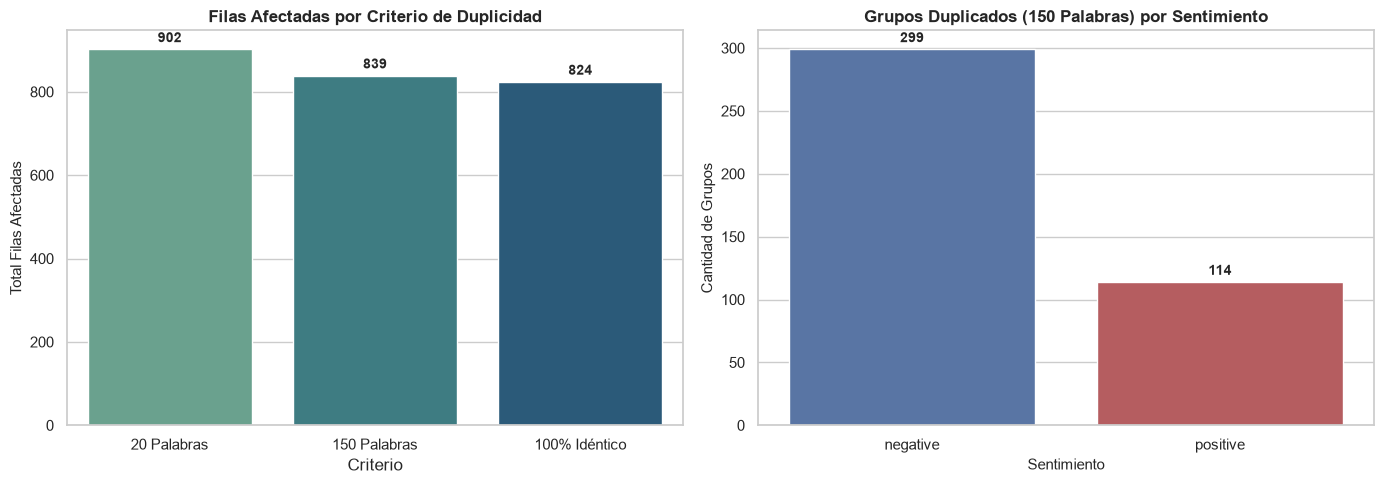

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Comparación de grupos y filas entre 20 y 150 palabras
metricas_df = pd.DataFrame({
    'Criterio': ['20 Palabras', '150 Palabras', '100% Idéntico'],
    'Grupos': [n_grupos_20, n_grupos_150, n_grupos_full],
    'Filas Afectadas': [n_filas_20, n_filas_150, n_filas_full]
})

sns.barplot(data=metricas_df, x='Criterio', y='Filas Afectadas', hue='Criterio', legend=False, ax=axes[0], palette='crest')
axes[0].set_title('Filas Afectadas por Criterio de Duplicidad', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Filas Afectadas', fontsize=11)
for p in axes[0].patches:
    altura = int(p.get_height())
    axes[0].annotate(f'{altura:,}', (p.get_x() + p.get_width() / 2., altura),
                     ha='center', va='bottom', fontsize=10, fontweight='semibold',
                     xytext=(0, 3), textcoords='offset points')

# 2. Distribución de duplicados (150 palabras) por sentimiento
dist_sent_150 = df_duplicadas_150['sentiment'].value_counts()
sns.barplot(x=dist_sent_150.index, y=dist_sent_150.values, hue=dist_sent_150.index, legend=False, ax=axes[1], palette=['#4c72b0', '#c44e52'])
axes[1].set_title('Grupos Duplicados (150 Palabras) por Sentimiento', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentimiento', fontsize=11)
axes[1].set_ylabel('Cantidad de Grupos', fontsize=11)
for p in axes[1].patches:
    altura = int(p.get_height())
    axes[1].annotate(f'{altura}', (p.get_x() + p.get_width() / 2., altura),
                     ha='center', va='bottom', fontsize=10, fontweight='semibold',
                     xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


## 7. Exportación del DataFrame de Duplicados (150 Palabras) a `data/`


In [14]:
# Ruta de guardado en la carpeta data
ruta_salida = 'data/reviews_duplicadas.csv'

df_export = df_duplicadas_150[[
    'primeras_150_palabras',
    'sentiment',
    'total_duplicadas',
    'ids_texto',
    'review'
]].rename(columns={'ids_texto': 'ids_duplicadas'})

df_export.to_csv(ruta_salida, index=False)
print(f"Archivo actualizado exitosamente en: {ruta_salida}")
print(f"Total de registros exportados: {len(df_export)}")
df_export.head(5)


Archivo actualizado exitosamente en: data/reviews_duplicadas.csv
Total de registros exportados: 413


,primeras_150_palabras,sentiment,total_duplicadas,ids_duplicadas,review
0,Loved today's show!!! It was a variety and not...,positive,5,"5213, 12531, 16340, 18467, 30658",Loved today's show!!! It was a variety and not...
1,"Hilarious, clean, light-hearted, and quote-wor...",positive,4,"7991, 8801, 33413, 34155","Hilarious, clean, light-hearted, and quote-wor..."
2,You do realize that you've been watching the E...,negative,3,"10383, 27265, 43926",You do realize that you've been watching the E...
3,Nickelodeon has gone down the toilet. They hav...,negative,3,"4728, 42756, 47705",Nickelodeon has gone down the toilet. They hav...
4,Robert Jordan is a television star. Robert Jor...,positive,3,"12166, 17801, 29355",Robert Jordan is a television star. Robert Jor...


## 8. Conclusiones y Comparativa Teórica

| Métrica | 20 Palabras | 150 Palabras | Texto 100% Idéntico |
| :--- | :---: | :---: | :---: |
| **Grupos Duplicados Únicos** | **443** | **413** | **406** |
| **Filas Involucradas** | **902** | **839** | **824** |
| **Porcentaje del Dataset** | $1.80\%$ | $1.68\%$ | $1.65\%$ |
| **Riesgo de Falsos Positivos** | Bajo-Moderado | Prácticamente Nulo | Nulo |
| **Capacidad de Detección de Modificaciones** | Alta | Específica | Nula |

### ¿Qué nos enseña la transición de 20 a 150 palabras?
1. **Convergencia Asintótica:** Al elevar $k$ a 150 palabras, el número de grupos detectados ($413$) se aproxima casi en su totalidad al conjunto de duplicados exactos ($406$). Sólo existen **7 grupos** donde las primeras 150 palabras coinciden y el cuerpo restante presenta diferencias (como notas de censura, firmas o comentarios añadidos).
2. **Robustez en NLP:** Usar 150 palabras garantiza con certidumbre matemática que no se están colisionando reseñas independientes con aperturas cliché, protegiendo tanto la representatividad del vocabulario como la pureza de la partición de entrenamiento/prueba.
